## Setup for EDA and time series 

In [1]:
#pip install --upgrade pip
#%pip install keras
#%pip install tensorflow 

In [2]:
#%pip install keras

In [3]:
 #%pip install tensorflow 

In [4]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.callbacks import EarlyStopping

# this for time series
#import statsmodels.formula.api as smf
#from statsmodels.tsa.seasonal import seasonal_decompose
#from scipy.ndimage import gaussian_filter
#from calendar import monthrange
#from calendar import month_name
#from sklearn.metrics import mean_squared_error
#from math import sqrt
#from statsmodels.tsa.stattools import adfuller,kpss
#from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.arima_model import ARIMA
#from statsmodels.graphics.tsaplots import plot_pacf
#from pmdarima.arima import auto_arima
#import statsmodels.graphics.tsaplots as tsaplot
#from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing

#import tensorflow as tf
#from keras.models import Sequential
#from keras.layers import LSTM, Dense

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import load_model
import time


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [5]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [6]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [7]:
#res_df.dtypes

In [8]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [9]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [10]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [11]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [12]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [13]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [14]:
data_df_gwh = data_df_mwh.copy()

In [15]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [16]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [17]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [18]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [19]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [20]:

data_df= data_df_gwh.copy()

In [21]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [22]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [23]:
##data_df.columns

In [24]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [25]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files
#main_0  = 'Total_energy_generation_gwh' # This is only for energy
main_0  = 'Solar_gwh' # for all other columns
title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
#target = 'Total_energy_generation_gwh'
target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Solar energy in GWh
Solar(GWh)


### Here we set the function for line plot  

In [26]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



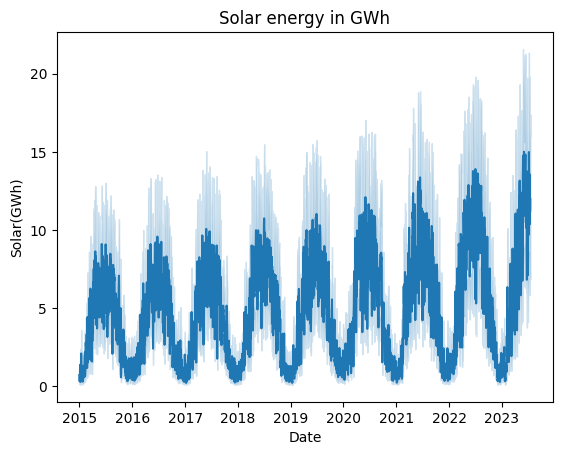

In [27]:
## Energy development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
ax.set(title=title_main, ylabel= ylable_target);

In [28]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [29]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [30]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

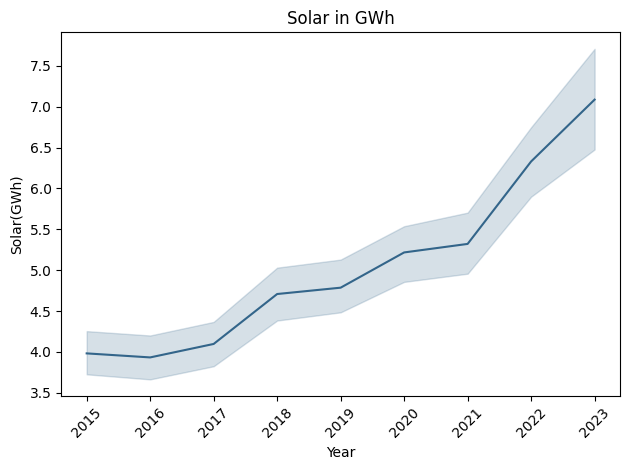

In [31]:
average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [32]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [33]:
daily_data_df

,Year,Month,Day,Dayofyear,Hour,Solar_gwh
Date,,,,,,
2015-01-01,2015,1,1,1,0,0.00000
2015-01-01,2015,1,1,1,1,0.00000
2015-01-01,2015,1,1,1,2,0.00000
2015-01-01,2015,1,1,1,3,0.00000
2015-01-01,2015,1,1,1,4,0.00000
...,...,...,...,...,...,...
2023-07-17,2023,7,17,198,18,10.08425
2023-07-17,2023,7,17,198,19,4.72400
2023-07-17,2023,7,17,198,20,1.51125


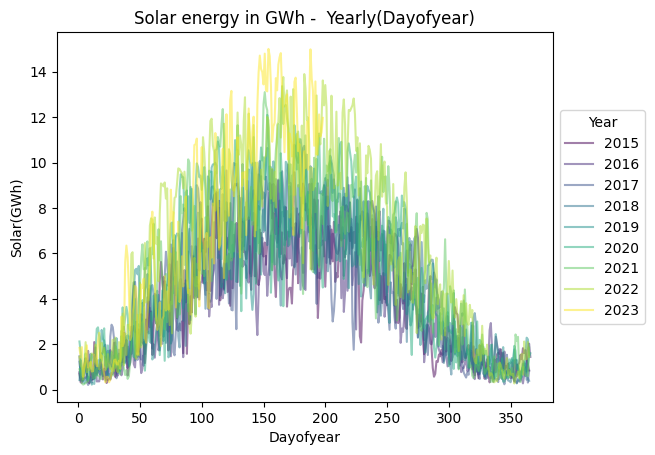

In [34]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [35]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [36]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

### Creating train and test sets
We will split our data and take the first part as our training set and the years after 2016 as a test set. Since we are dealing with a time series here we cannot split randomly as we are used to do. 

In [37]:
# Split data into train and test set
#window=365#*24
#df_arima = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_arima = df_arima.dropna()
#

#df_arima = data_df[target]
#train_test_split_ratio = int(len(df_arima)*0.8)
#train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]

# Plotting the train and test set
#plt.figure(figsize=(10,6))
#plt.xlabel('Time')
#plt.ylabel(ylable_target)
#plt.plot(train_data, 'red', label='Train data')
#plt.plot(test_data, 'black', label='Test data')
#plt.legend()
#plt.xticks([])
#plt.xlim(pd.to_datetime("2015"),pd.to_datetime("2023"))

In [38]:
dfs = data_df[['Date',  target]]


In [184]:
#print(dfs.shape)
#plt.figure()
#plt.plot(dfs['Date'], dfs[target])
#plt.autoscale(enable=True, axis='x', tight=True)
#plt.show();

### Modeling with LSTM 

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_2314/3118237533.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/5
9985/9985 - 29s - loss: 0.0212 - val_loss: 0.0248 - 29s/epoch - 3ms/step
Epoch 2/5
9985/9985 - 25s - loss: 0.0207 - val_loss: 0.0230 - 25s/epoch - 2ms/step
Epoch 3/5
9985/9985 - 26s - loss: 0.0205 - val_loss: 0.0234 - 26s/epoch - 3ms/step
Epoch 4/5
9985/9985 - 26s - loss: 0.0204 - val_loss: 0.0231 - 26s/epoch - 3ms/step
Epoch 5/5
9985/9985 - 26s - loss: 0.0202 - val_loss: 0.0228 - 26s/epoch - 3ms/step
Epoch 1/5
19968/19968 - 44s - loss: 0.0215 - val_loss: 0.0273 - 44s/epoch - 2ms/step
Epoch 2/5
19968/19968 - 43s - loss: 0.0213 - val_loss: 0.0269 - 43s/epoch - 2ms/step
Epoch 3/5
19968/19968 - 44s - loss: 0.0208 - val_loss: 0.0259 - 44s/epoch - 2ms/step
Epoch 4/5
19968/19968 - 43s - loss: 0.0205 - val_loss: 0.0269 - 43s/epoch - 2ms/step
Epoch 5/5
19968/19968 - 43s - loss: 0.0203 - val_loss: 0.0257 - 43s/epoch - 2ms/step
Epoch 1/5
29951/29951 - 60s - loss: 0.0220 - val_loss: 0.0322 - 60s/epoch - 2ms/step
Epoch 2/5
29951/29951 - 61s - loss: 0.0216 - val_loss: 0.0321 - 61s/epoch -

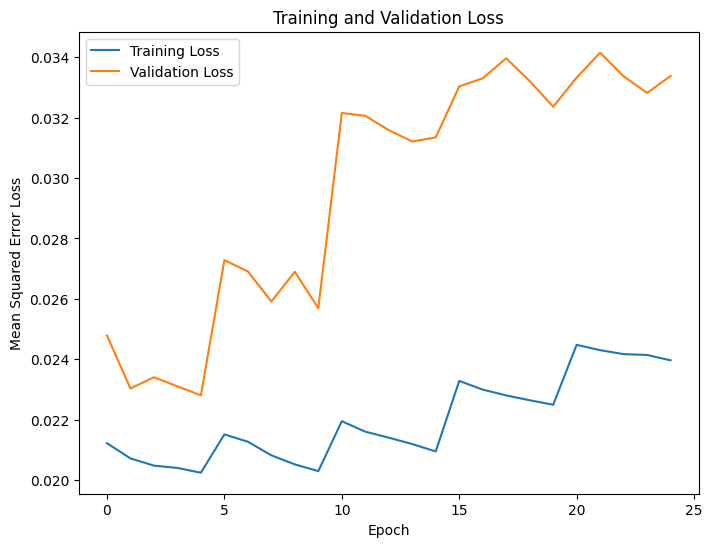

KeyError: 'Date'

<Figure size 1000x600 with 0 Axes>

In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Sort the DataFrame by date in ascending order
dfs = dfs.sort_values(by='Date', ascending=True)

# Create dataframe
data = dfs.copy()

# Redefine number of input time sequential steps
num = 3

# Set index
data.index = data.Date
data.drop('Date', axis=1, inplace=True)

# Create train and test sets with time-based splitting
train_size = int(len(data) * 0.8)
train, valid = data.iloc[:train_size], data.iloc[train_size:]

# Separate the features and target variable
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
valid_scaled = scaler.transform(valid)

X_train, y_train = [], []
for i in range(num, len(train_scaled)):
    X_train.append(train_scaled[i - num:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
history = {'train_loss': [], 'val_loss': []}  # Initialize a dictionary to store both training and validation losses
for train_index, test_index in tscv.split(X_train):
    X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
    y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

    h = model.fit(X_train_cv, y_train_cv, epochs=5, batch_size=1, verbose=2, validation_data=(X_test_cv, y_test_cv))
    history['train_loss'].extend(h.history['loss'])
    history['val_loss'].extend(h.history['val_loss'])

# Prepare validation data for predictions
inputs = valid_scaled[len(valid_scaled) - num:]
X_test = np.array([inputs])

# Make predictions on the validation set
closing_price = []
for _ in range(len(valid_scaled)):
    predicted = model.predict(X_test)
    closing_price.append(predicted[0][0])
    X_test = np.roll(X_test, -1)
    X_test[0, -1] = predicted

# Inverse transform predictions and original values
closing_price = np.array(closing_price).reshape(-1, 1)
closing_price = scaler.inverse_transform(closing_price)

y_true = scaler.inverse_transform(valid_scaled)[:, 0]

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
rmse = np.sqrt(mean_squared_error(y_true, closing_price))
mse = mean_squared_error(y_true, closing_price)
mae = mean_absolute_error(y_true, closing_price)
r2 = r2_score(y_true, closing_price)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot both training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:train_size], train[target], 'orange', label='Train data')
plt.plot(data['Date'][train_size:], valid[target], 'red', label='Test data')
plt.plot(data['Date'][train_size:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


59843/59843 - 920s - loss: 3.5529e-04 - 920s/epoch - 15ms/step
468/468 [==============================] - 7s 13ms/step


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_71768/1922016452.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = closing_price


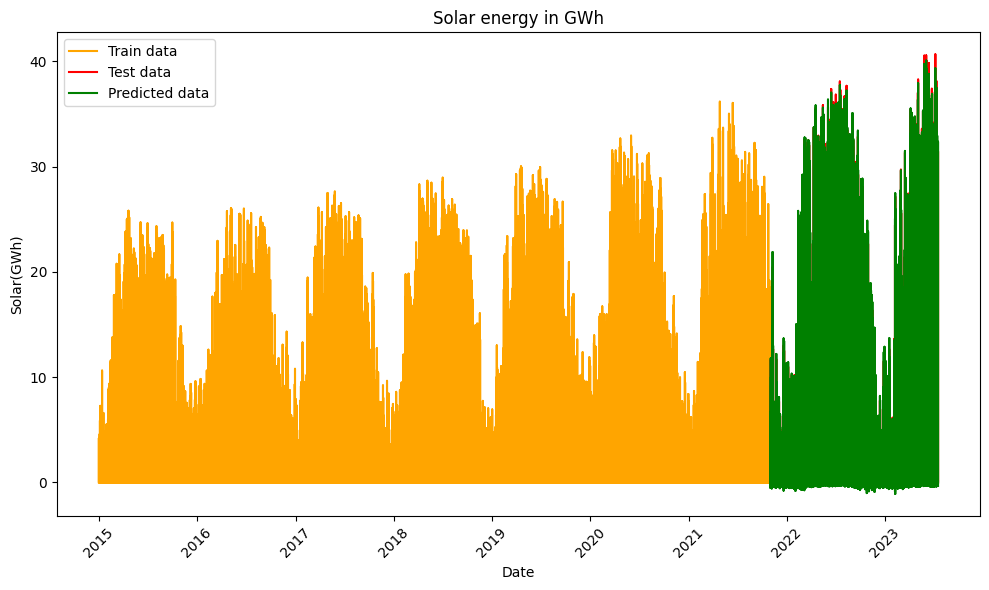

In [42]:
# 'Date' format y-m-d
#creating dataframe
data = dfs.sort_index(ascending=True, axis=0)
new_data = pd.DataFrame(index=range(0,len(dfs)),columns=['Date', target])
for i in range(0,len(data)):
    new_data['Date'][i] = data['aDate'][i]
    new_data[target][i] = data[target][i]

#setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

#creating train and test sets
dataset = new_data.values

train = dataset[0:int(len(dataset)*0.8),:]
valid = dataset[int(len(dataset)*0.8):,:]

#converting dataset into x_train and y_train
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

x_train, y_train = [], []
for i in range(60,len(train)):
    x_train.append(scaled_data[i-60:i,0])
    y_train.append(scaled_data[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=1, batch_size=1, verbose=2)

#predicting 246 values, using past 60 from the train data
inputs = new_data[len(new_data) - len(valid) - 60:].values
inputs = inputs.reshape(-1,1)
inputs  = scaler.transform(inputs)

X_test = []
for i in range(60,inputs.shape[0]):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

#for plotting
train = new_data[:int(len(dataset)*0.8)]
valid = new_data[int(len(dataset)*0.8):]
valid['Predictions'] = closing_price

#calculating score matrices and residuals
rms=np.sqrt(np.mean(np.power((valid[target]-valid['Predictions']),2)))
ms=np.mean(np.power((valid[target]-valid['Predictions']),2))
ma=np.mean(np.power((valid[target]-valid['Predictions']),1))
R2= 1-np.mean(np.power((valid[target]-valid['Predictions']),2))/(np.mean(np.power((valid[target]-np.mean(valid)),2)))

print("Root Mean Squared Error:", rms)
print("Mean Squared Error:", ms)
print("Mean Absolute Error:", ma)
print("R^2:", r2)
residuals =valid[target]-valid['Predictions']


#plt.plot(train[target])
#plt.plot(valid[[target,'Predictions']])
#plt.show()
plt.figure(figsize=(10,6))
plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid[target],  'red', label='Test data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


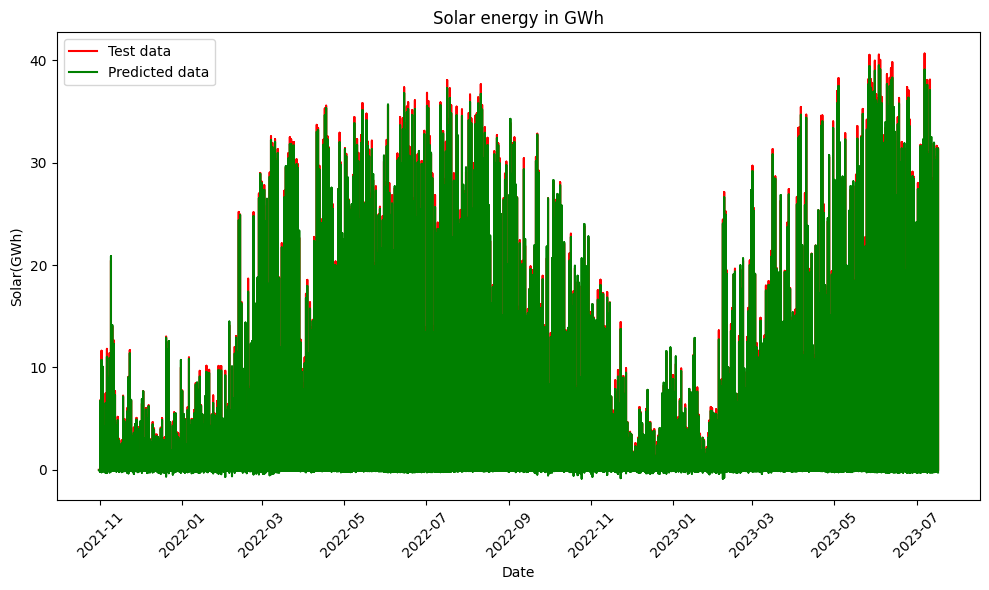

In [185]:
plt.figure(figsize=(10,6))
#plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid[target],  'red', label='Test data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [186]:
#calculating score matrices and residuals
rms=np.sqrt(np.mean(np.power((valid[target]-valid['Predictions']),2)))
ms=np.mean(np.power((valid[target]-valid['Predictions']),2))
ma=np.mean(np.power((valid[target]-valid['Predictions']),1))
R2= 1-np.mean(np.power((valid[target]-valid['Predictions']),2))/(np.mean(np.power((valid[target]-np.mean(valid)),2)))

print("Root Mean Squared Error:", rms)
print("Mean Squared Error:", ms)
print("Mean Absolute Error:", ma)
print("R^2:", r2)
residuals =valid[target]-valid['Predictions']
#print("Residuals:", residuals)
#print("Score Matrices:", rms, ms, mae,R2)
#residuals = valid - closing_price
#print("Residuals:", residuals)

Root Mean Squared Error: 0.5171507533605991
Mean Squared Error: 0.26744490170143526
Mean Absolute Error: 0.17563575069591375
R^2: 0.9970566763589807


In [187]:
#calculating errors
y_test = valid[target]
y_pred = valid['Predictions']#closing_price
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)

Root Mean Squared Error: 0.5171507533605973
Mean Squared Error: 0.2674449017014334
Mean Absolute Error: 0.30386698585451044
R^2: 0.9970566763589807


59803/59803 - 863s - loss: 3.8497e-04 - 863s/epoch - 14ms/step
468/468 [==============================] - 5s 10ms/step


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_71768/3413630098.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = closing_price


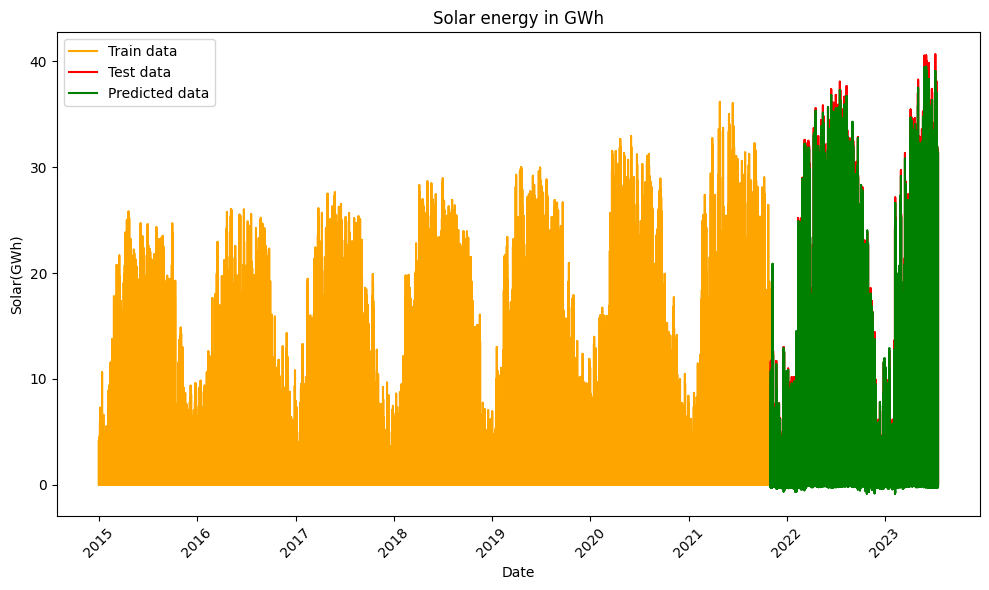

In [71]:
# 'Date' format y-m-d
#creating dataframe
data = dfs.sort_index(ascending=True, axis=0)
new_data = pd.DataFrame(index=range(0,len(dfs)),columns=['Date', target])
for i in range(0,len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data[target][i] = data[target][i]

# Redefine num= 60 origional
num=100

#setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

#creating train and test sets
dataset = new_data.values

train = dataset[0:int(len(dataset)*0.8),:]
valid = dataset[int(len(dataset)*0.8):,:]

#converting dataset into x_train and y_train
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

x_train, y_train = [], []
for i in range(num,len(train)):
    x_train.append(scaled_data[i-num:i,0])
    y_train.append(scaled_data[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=1, batch_size=1, verbose=2)

#predicting 246 values, using past 60 from the train data
inputs = new_data[len(new_data) - len(valid) - num:].values
inputs = inputs.reshape(-1,1)
inputs  = scaler.transform(inputs)


X_test = []
for i in range(num,inputs.shape[0]):
    X_test.append(inputs[i-num:i,0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

#for plotting
train = new_data[:int(len(dataset)*0.8)]
valid = new_data[int(len(dataset)*0.8):]
valid['Predictions'] = closing_price
#plt.plot(train[target])
#plt.plot(valid[[target,'Predictions']])
#plt.show()

plt.figure(figsize=(10,6))
plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid[target],  'red', label='Test data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [188]:
#calculating errors
y_test = valid[target]
y_pred = valid['Predictions']#closing_price
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)

Root Mean Squared Error: 0.5171507533605973
Mean Squared Error: 0.2674449017014334
Mean Absolute Error: 0.30386698585451044
R^2: 0.9970566763589807


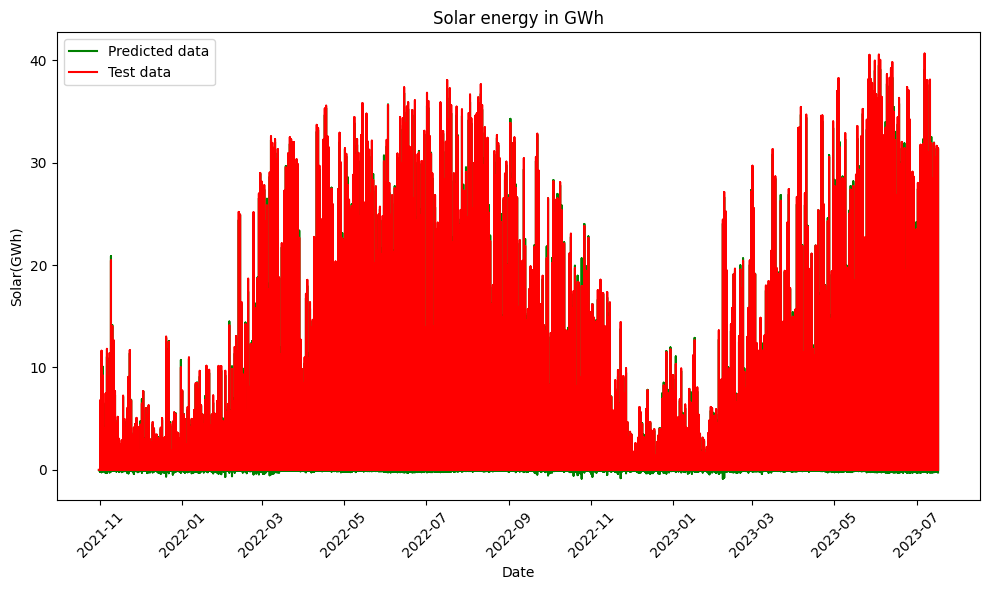

In [189]:
#df['Date'].plot(xlim=('2020-01-01', '2020-12-31'))
lim1 = dfs['Date']>'2023-01-01'
lim2 = dfs['Date']>'2023-12-31'
plt.figure(figsize=(10,6))
#plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.plot(valid[target],  'red', label='Test data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
#plt.xlim(lim1,lim2)
plt.tight_layout()
plt.legend()
plt.show()
#df[df['Date'] <= x_limit]
#plt.xlim(pd.to_datetime(dfs['Date']) >= 2023-01-01,  pd.to_datetime(dfs['Date']) <= 2023-07-17). 

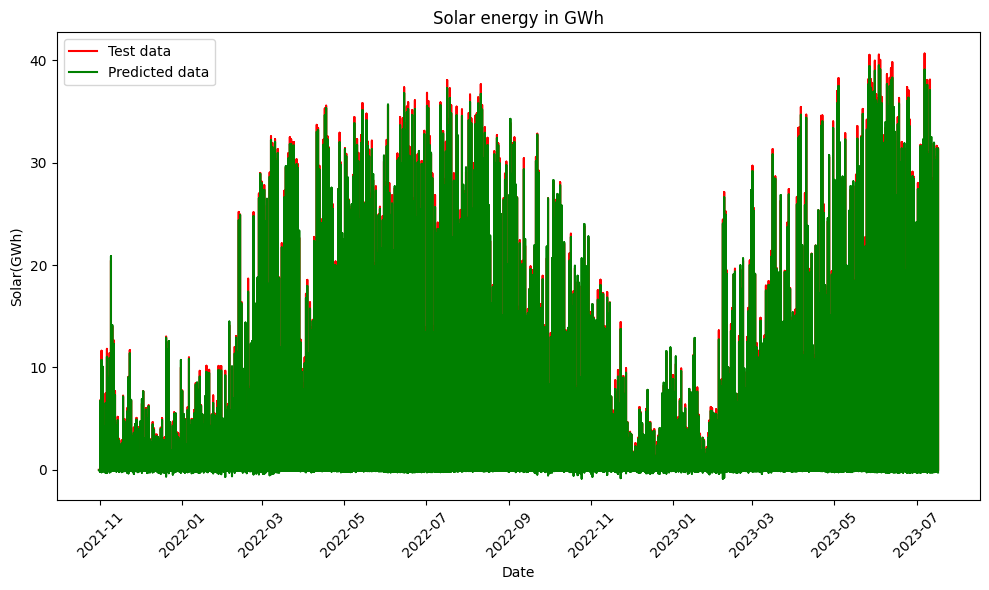

In [190]:
#df['Date'].plot(xlim=('2020-01-01', '2020-12-31'))
lim1 = dfs['Date']>'2023-01-01'
lim2 = dfs['Date']>'2023-12-31'
plt.figure(figsize=(10,6))
#plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid[target],  'red', label='Test data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
#plt.xlim(lim1,lim2)
plt.tight_layout()
plt.legend()
plt.show()

Epoch 1/20
59803/59803 - 1572s - loss: 3.8716e-04 - 1572s/epoch - 26ms/step
Epoch 2/20
59803/59803 - 1339s - loss: 9.9083e-05 - 1339s/epoch - 22ms/step
Epoch 3/20
59803/59803 - 1585s - loss: 8.4443e-05 - 1585s/epoch - 27ms/step
Epoch 4/20
59803/59803 - 1302s - loss: 7.6275e-05 - 1302s/epoch - 22ms/step
Epoch 5/20
59803/59803 - 1230s - loss: 7.0271e-05 - 1230s/epoch - 21ms/step
Epoch 6/20
59803/59803 - 1192s - loss: 6.5863e-05 - 1192s/epoch - 20ms/step
Epoch 7/20
59803/59803 - 1136s - loss: 6.3511e-05 - 1136s/epoch - 19ms/step
Epoch 8/20
59803/59803 - 1087s - loss: 6.1096e-05 - 1087s/epoch - 18ms/step
Epoch 9/20
59803/59803 - 1323s - loss: 5.9459e-05 - 1323s/epoch - 22ms/step
Epoch 10/20
59803/59803 - 1371s - loss: 5.6986e-05 - 1371s/epoch - 23ms/step
Epoch 11/20
59803/59803 - 1482s - loss: 5.6274e-05 - 1482s/epoch - 25ms/step
Epoch 12/20
59803/59803 - 1497s - loss: 5.4926e-05 - 1497s/epoch - 25ms/step
Epoch 13/20
59803/59803 - 1544s - loss: 5.3696e-05 - 1544s/epoch - 26ms/step
Epoch 14

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_71768/2385267381.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = closing_price


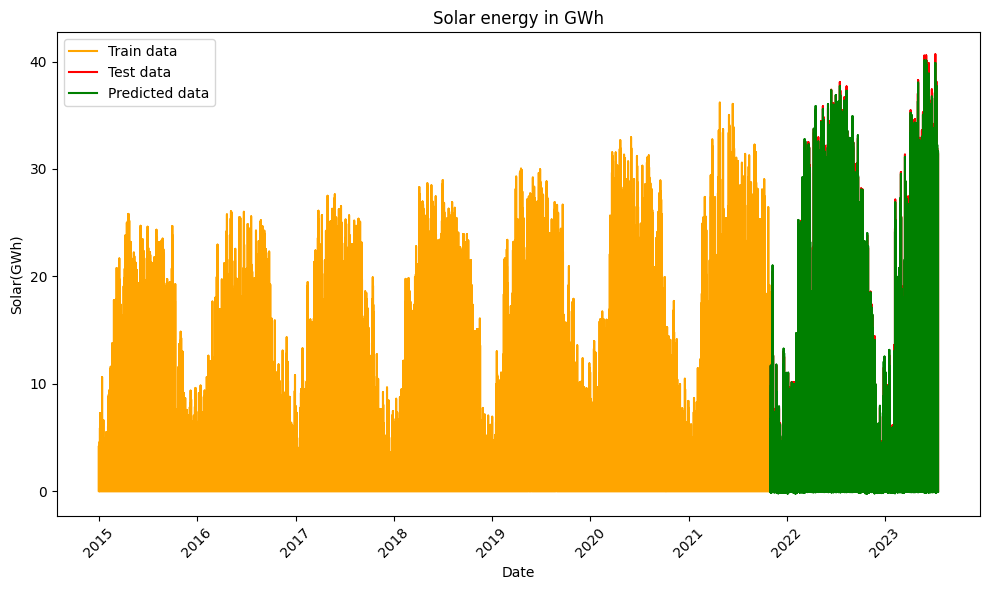

In [191]:
#creating dataframe
data = dfs.sort_index(ascending=True, axis=0)
new_data = pd.DataFrame(index=range(0,len(dfs)),columns=['Date', target])
for i in range(0,len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data[target][i] = data[target][i]

# Redefine num= 60 origional
num=100

#setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

#creating train and test sets
dataset = new_data.values

train = dataset[0:int(len(dataset)*0.8),:]
valid = dataset[int(len(dataset)*0.8):,:]

#converting dataset into x_train and y_train
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

x_train, y_train = [], []
for i in range(num,len(train)):
    x_train.append(scaled_data[i-num:i,0])
    y_train.append(scaled_data[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=20, batch_size=1, verbose=2)

#predicting 246 values, using past 60 from the train data
inputs = new_data[len(new_data) - len(valid) - num:].values
inputs = inputs.reshape(-1,1)
inputs  = scaler.transform(inputs)


X_test = []
for i in range(num,inputs.shape[0]):
    X_test.append(inputs[i-num:i,0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

#for plotting
train = new_data[:int(len(dataset)*0.8)]
valid = new_data[int(len(dataset)*0.8):]
valid['Predictions'] = closing_price
#plt.plot(train[target])
#plt.plot(valid[[target,'Predictions']])
#plt.show()

plt.figure(figsize=(10,6))
plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid[target],  'red', label='Test data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

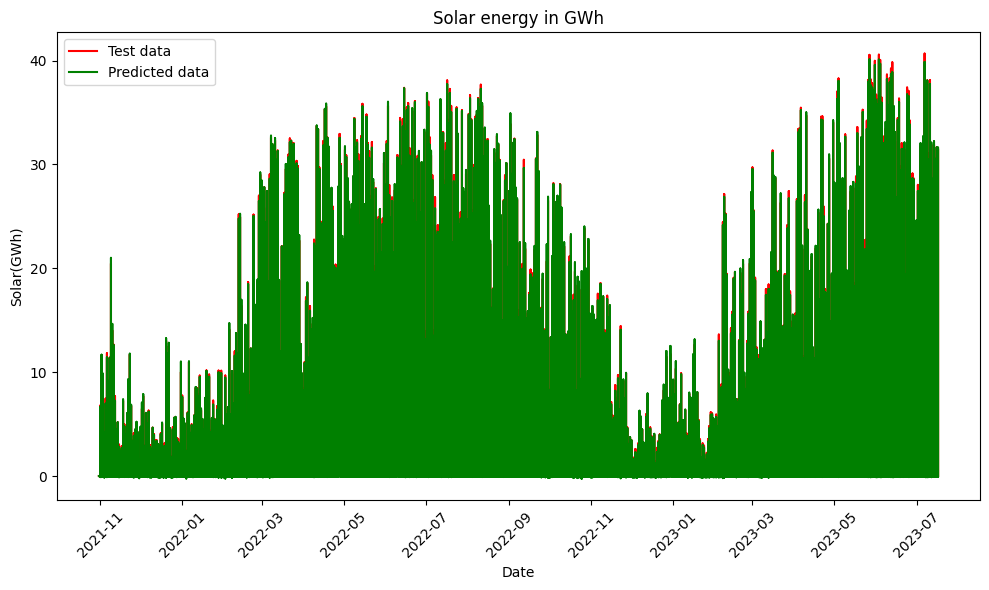

In [192]:
plt.figure(figsize=(10,6))
#plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid[target],  'red', label='Test data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [193]:
#calculating errors
y_test = valid[target]
y_pred = valid['Predictions']#closing_price
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)

Root Mean Squared Error: 0.3676327029760854
Mean Squared Error: 0.13515380429750262
Mean Absolute Error: 0.20977001586185334
R^2: 0.9985125856397643


In [194]:
#calculating score matrices and residuals
rms=np.sqrt(np.mean(np.power((valid[target]-valid['Predictions']),2)))
ms=np.mean(np.power((valid[target]-valid['Predictions']),2))
ma=np.mean(np.power((valid[target]-valid['Predictions']),1))
R2= 1-np.mean(np.power((valid[target]-valid['Predictions']),2))/(np.mean(np.power((valid[target]-np.mean(valid)),2)))

print("Root Mean Squared Error:", rms)
print("Mean Squared Error:", ms)
print("Mean Absolute Error:", ma)
print("R^2:", r2)
residuals =valid[target]-valid['Predictions']
#print("Residuals:", residuals)
#print("Score Matrices:", rms, ms, mae,R2)
#residuals = valid - closing_price
#print("Residuals:", residuals)

Root Mean Squared Error: 0.3676327029760856
Mean Squared Error: 0.13515380429750276
Mean Absolute Error: 0.1241794706455445
R^2: 0.9985125856397643


In [195]:
# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
#plt.title('Model Loss')
#plt.xlabel('Epoch')
#plt.ylabel('Mean Squared Error')
#plt.show()


NameError: name 'history' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
dfs = data_df[['Date',  target]]

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_71768/141538935.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/10
59902/59902 [==============================] - 50s 814us/step - loss: 0.0029
Epoch 2/10
59902/59902 [==============================] - 51s 856us/step - loss: 0.0027
Epoch 3/10
59902/59902 [==============================] - 46s 763us/step - loss: 0.0027
Epoch 4/10
59902/59902 [==============================] - 45s 757us/step - loss: 0.0027
Epoch 5/10
59902/59902 [==============================] - 45s 753us/step - loss: 0.0027
Epoch 6/10
59902/59902 [==============================] - 45s 752us/step - loss: 0.0027
Epoch 7/10
59902/59902 [==============================] - 45s 754us/step - loss: 0.0027
Epoch 8/10
59902/59902 [==============================] - 45s 754us/step - loss: 0.0027
Epoch 9/10
59902/59902 [==============================] - 45s 755us/step - loss: 0.0027
Epoch 10/10
59902/59902 [==============================] - 45s 755us/step - loss: 0.0027


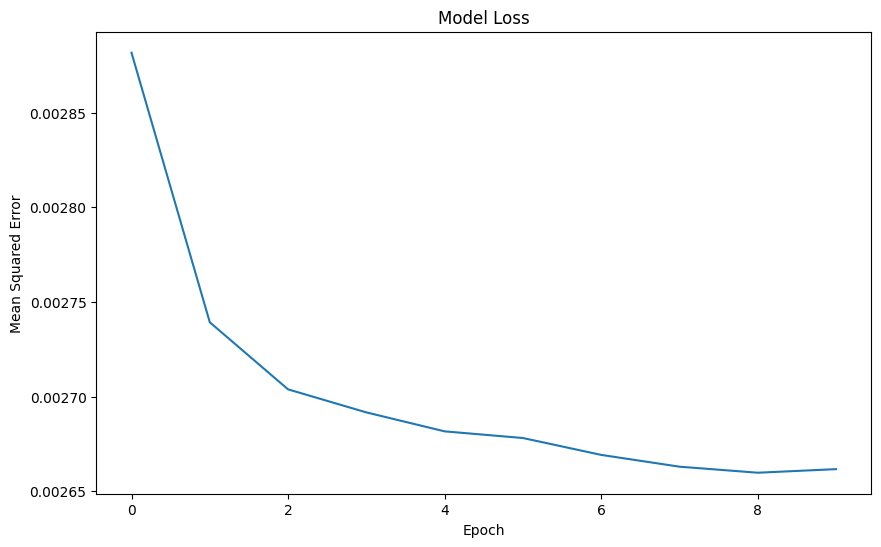

468/468 [==============================] - 1s 452us/step


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_71768/614551225.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/30
14971/14971 - 73s - loss: 5.7182e-04 - 73s/epoch - 5ms/step
Epoch 2/30
14971/14971 - 73s - loss: 1.0501e-04 - 73s/epoch - 5ms/step
Epoch 3/30
14971/14971 - 76s - loss: 8.9954e-05 - 76s/epoch - 5ms/step
Epoch 4/30
14971/14971 - 73s - loss: 8.0745e-05 - 73s/epoch - 5ms/step
Epoch 5/30
14971/14971 - 73s - loss: 7.5950e-05 - 73s/epoch - 5ms/step
Epoch 6/30
14971/14971 - 72s - loss: 7.3840e-05 - 72s/epoch - 5ms/step
Epoch 7/30
14971/14971 - 76s - loss: 7.0663e-05 - 76s/epoch - 5ms/step
Epoch 8/30
14971/14971 - 86s - loss: 6.8087e-05 - 86s/epoch - 6ms/step
Epoch 9/30
14971/14971 - 77s - loss: 6.7927e-05 - 77s/epoch - 5ms/step
Epoch 10/30
14971/14971 - 91s - loss: 6.5878e-05 - 91s/epoch - 6ms/step
Epoch 11/30
14971/14971 - 92s - loss: 6.4689e-05 - 92s/epoch - 6ms/step
Epoch 12/30
14971/14971 - 93s - loss: 6.3845e-05 - 93s/epoch - 6ms/step
Epoch 13/30
14971/14971 - 105s - loss: 6.2652e-05 - 105s/epoch - 7ms/step
Epoch 14/30
14971/14971 - 126s - loss: 6.0621e-05 - 126s/epoch - 8ms/st

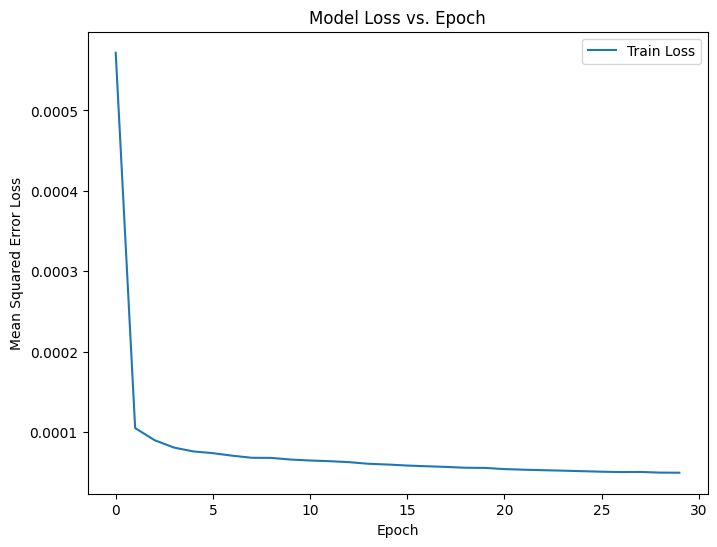

RMSE: 0.61
MSE: 0.37
MAE: 0.38
R2 Score: 1.00


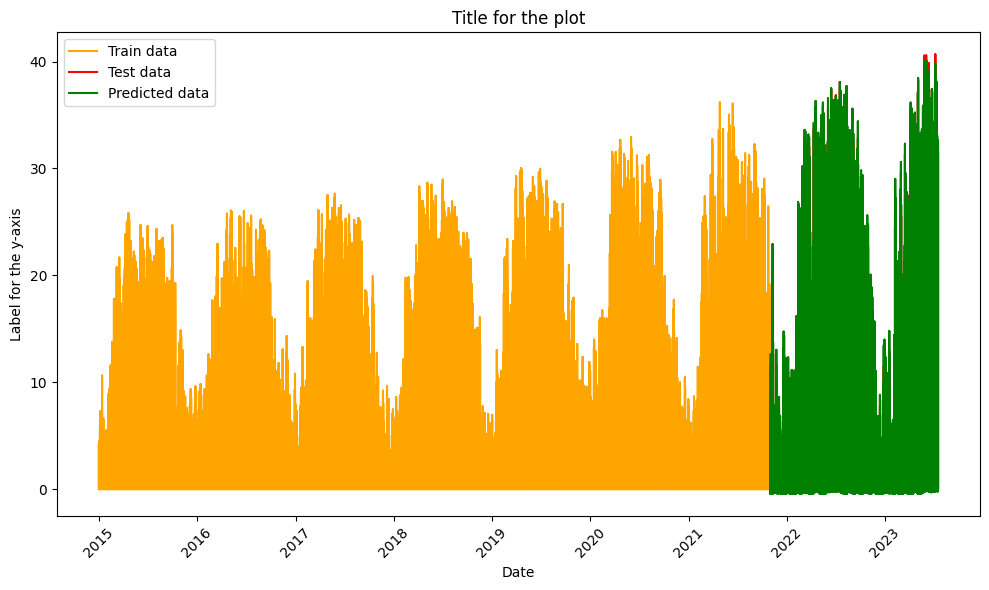

In [330]:
# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Creating dataframe
data = dfs.sort_values(by='Date', ascending=True)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
for i in range(0, len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data[target][i] = data[target][i]

# Redefine num= 5 original
#Input Sequence Length: The purpose of num is to determine the length of the input sequences that will be fed into the LSTM model during training.
num = 20

# Setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# Creating train and test sets
dataset = new_data.values

train = dataset[0:int(len(dataset) * 0.8), :]
valid = dataset[int(len(dataset) * 0.8):, :]

# Converting dataset into x_train and y_train
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

x_train, y_train = [], []
for i in range(num, len(train)):
    x_train.append(scaled_data[i - num:i, 0])
    y_train.append(scaled_data[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Create and fit the LSTM network

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
history = model.fit(x_train, y_train, epochs=30, batch_size=4, verbose=2)

# Plot model loss versus epoch
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Model Loss vs. Epoch')
plt.legend()
plt.show()

# Predicting 246 values, using past 60 from the train data
# ... (previous code)

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
y_true = valid_df[target].values
y_pred = valid_df['Predictions'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:int(len(dataset) * 0.8)], train[:, 0], 'orange', label='Train data')
plt.plot(data['Date'][int(len(dataset) * 0.8):], valid_df[target], 'red', label='Test data')
plt.plot(data['Date'][int(len(dataset) * 0.8):], valid_df['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


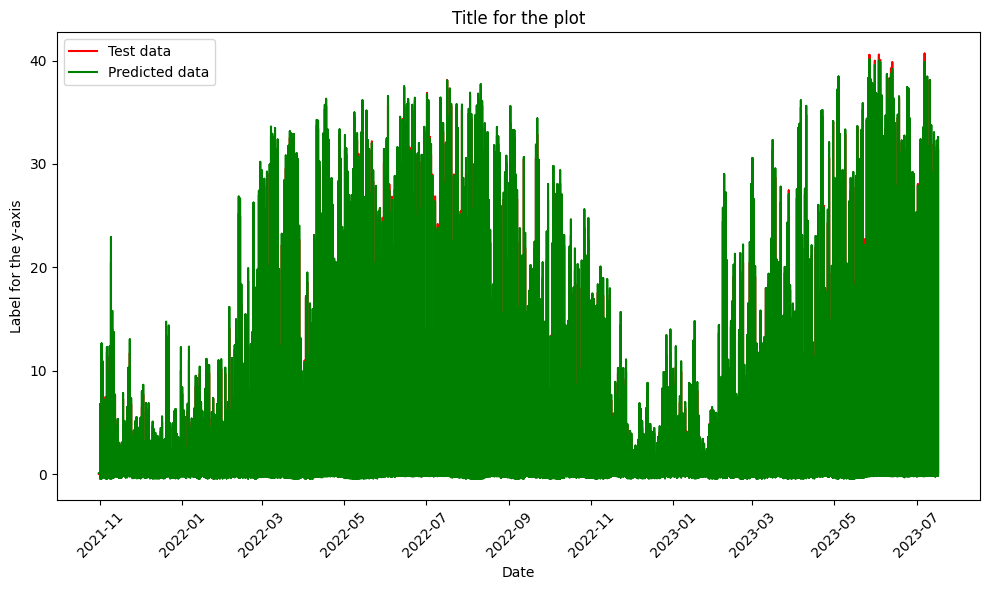

In [331]:
# Plot the results
plt.figure(figsize=(10, 6))
#plt.plot(data['Date'][:int(len(dataset) * 0.8)], train[:, 0], 'orange', label='Train data')
plt.plot(data['Date'][int(len(dataset) * 0.8):], valid_df[target], 'red', label='Test data')
plt.plot(data['Date'][int(len(dataset) * 0.8):], valid_df['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


In [ ]:
#above to it 27.07.2023 look above this cell

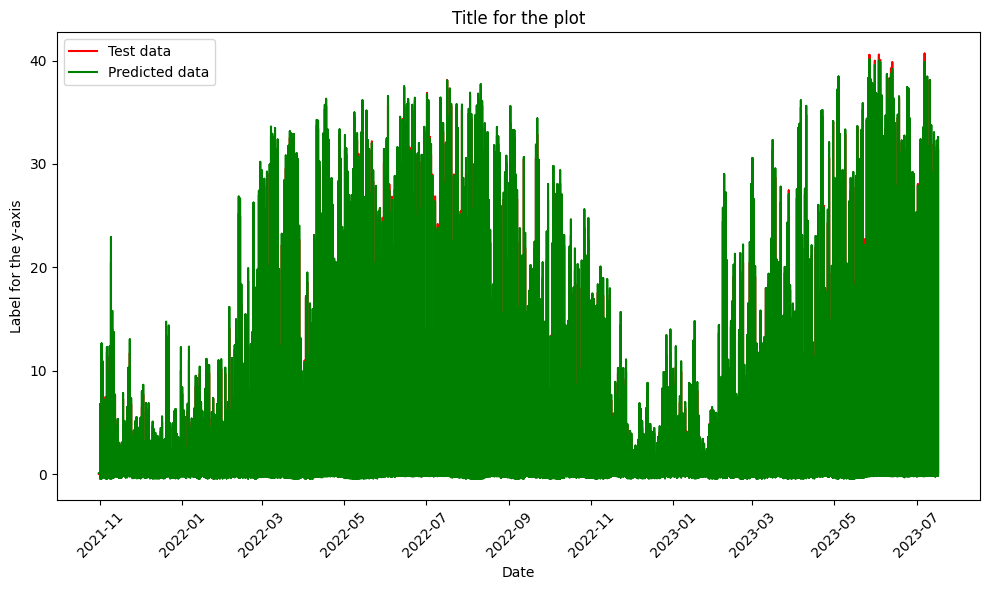

In [327]:
# Plot the results
plt.figure(figsize=(10, 6))
#plt.plot(data['Date'][:int(len(dataset) * 0.8)], train[:, 0], 'orange', label='Train data')
plt.plot(data['Date'][int(len(dataset) * 0.8):], valid_df[target], 'red', label='Test data')
plt.plot(data['Date'][int(len(dataset) * 0.8):], valid_df['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()#

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_71768/967463180.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/4
29951/29951 - 35s - loss: 7.1727e-04 - 35s/epoch - 1ms/step
Epoch 2/4
29951/29951 - 35s - loss: 2.0981e-04 - 35s/epoch - 1ms/step
Epoch 3/4
29951/29951 - 33s - loss: 1.6717e-04 - 33s/epoch - 1ms/step
Epoch 4/4
29951/29951 - 34s - loss: 1.5094e-04 - 34s/epoch - 1ms/step


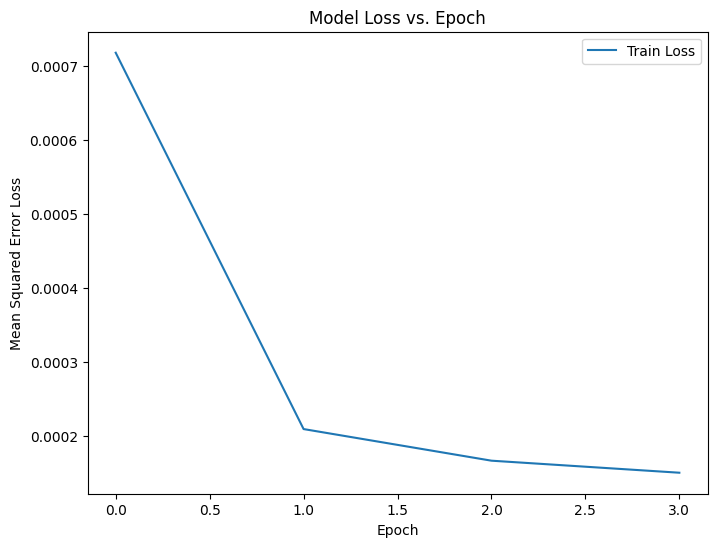

RMSE: 0.61
MSE: 0.37
MAE: 0.38
R2 Score: 1.00


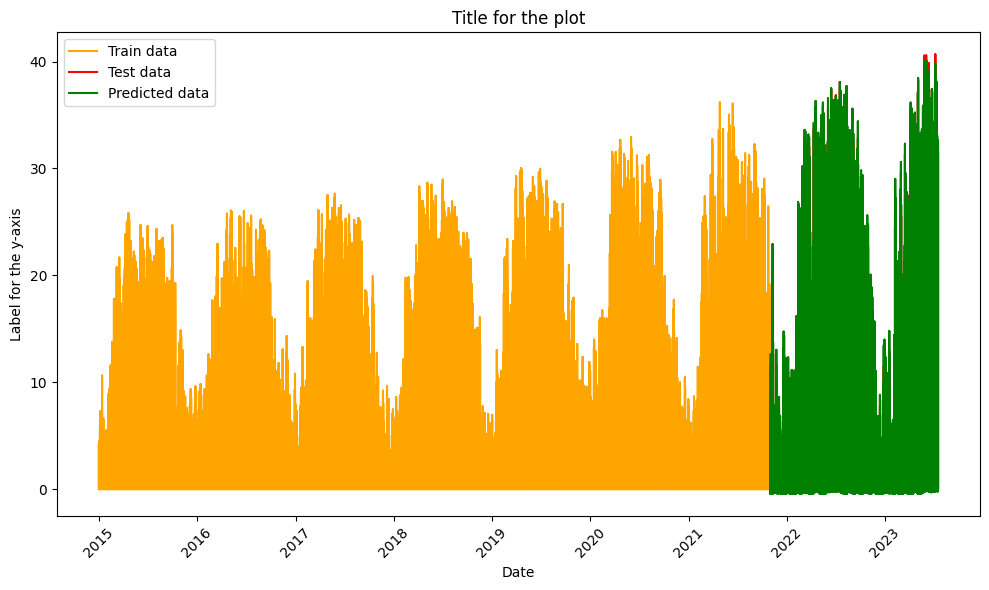

In [328]:
# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Creating dataframe
data = dfs.sort_values(by='Date', ascending=True)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
for i in range(0, len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data[target][i] = data[target][i]

# #Input Sequence Length: The purpose of num is to determine the length of the input sequences that will be fed into the LSTM model during training.
num = 2

# Setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# Creating train and test sets
dataset = new_data.values

train = dataset[0:int(len(dataset) * 0.8), :]
valid = dataset[int(len(dataset) * 0.8):, :]

# Converting dataset into x_train and y_train
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

x_train, y_train = [], []
for i in range(num, len(train)):
    x_train.append(scaled_data[i - num:i, 0])
    y_train.append(scaled_data[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Create and fit the LSTM network

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
history = model.fit(x_train, y_train, epochs=4, batch_size=2, verbose=2)

# Plot model loss versus epoch
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Model Loss vs. Epoch')
plt.legend()
plt.show()

# Predicting 246 values, using past 60 from the train data
# ... (previous code)

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
y_true = valid_df[target].values
y_pred = valid_df['Predictions'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:int(len(dataset) * 0.8)], train[:, 0], 'orange', label='Train data')
plt.plot(data['Date'][int(len(dataset) * 0.8):], valid_df[target], 'red', label='Test data')
plt.plot(data['Date'][int(len(dataset) * 0.8):], valid_df['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


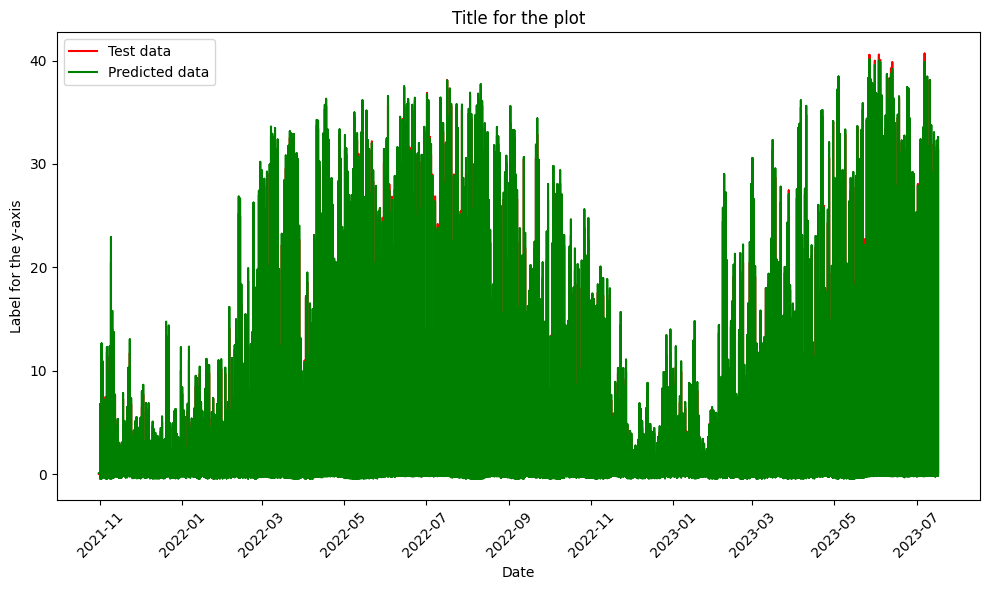

In [329]:
# Plot the results
plt.figure(figsize=(10, 6))
#plt.plot(data['Date'][:int(len(dataset) * 0.8)], train[:, 0], 'orange', label='Train data')
plt.plot(data['Date'][int(len(dataset) * 0.8):], valid_df[target], 'red', label='Test data')
plt.plot(data['Date'][int(len(dataset) * 0.8):], valid_df['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_71768/1096185420.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/4
4993/4993 - 10s - loss: 0.0210 - 10s/epoch - 2ms/step
Epoch 2/4
4993/4993 - 7s - loss: 0.0206 - 7s/epoch - 1ms/step
Epoch 3/4
4993/4993 - 6s - loss: 0.0205 - 6s/epoch - 1ms/step
Epoch 4/4
4993/4993 - 7s - loss: 0.0206 - 7s/epoch - 1ms/step
Epoch 1/4
9985/9985 - 19s - loss: 0.0219 - 19s/epoch - 2ms/step
Epoch 2/4
9985/9985 - 17s - loss: 0.0219 - 17s/epoch - 2ms/step
Epoch 3/4
9985/9985 - 18s - loss: 0.0218 - 18s/epoch - 2ms/step
Epoch 4/4
9985/9985 - 16s - loss: 0.0218 - 16s/epoch - 2ms/step
Epoch 1/4
14976/14976 - 20s - loss: 0.0239 - 20s/epoch - 1ms/step
Epoch 2/4
14976/14976 - 18s - loss: 0.0239 - 18s/epoch - 1ms/step
Epoch 3/4
14976/14976 - 21s - loss: 0.0238 - 21s/epoch - 1ms/step
Epoch 4/4
14976/14976 - 21s - loss: 0.0238 - 21s/epoch - 1ms/step
Epoch 1/4
19968/19968 - 35s - loss: 0.0268 - 35s/epoch - 2ms/step
Epoch 2/4
19968/19968 - 47s - loss: 0.0267 - 47s/epoch - 2ms/step
Epoch 3/4
19968/19968 - 44s - loss: 0.0265 - 44s/epoch - 2ms/step
Epoch 4/4
19968/19968 - 49s - lo

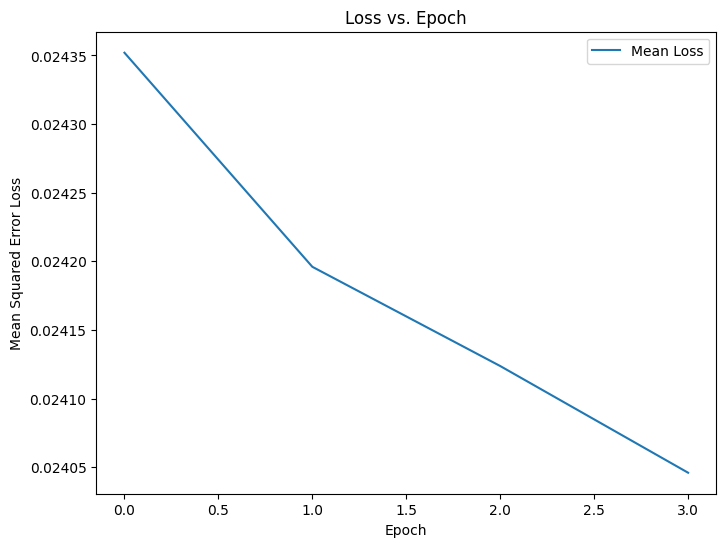

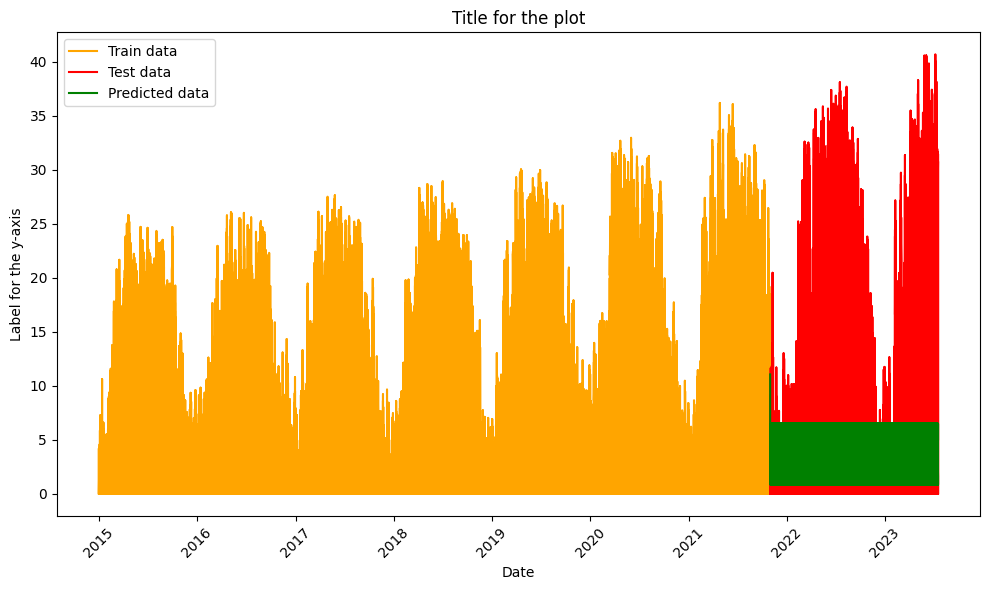

In [334]:
# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Create dataframe
data = dfs.sort_values(by='Date', ascending=True)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
new_data['Date'] = data['Date'].values
new_data[target] = data[target].values

# #Input Sequence Length: The purpose of num is to determine the length of the input sequences that will be fed into the LSTM model during training.
num = 2

# Set index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# Create train and test sets with time-based splitting
train_size = int(len(new_data) * 0.8)
train, valid = new_data.iloc[:train_size], new_data.iloc[train_size:]

# Separate the features and target variable
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
valid_scaled = scaler.transform(valid)

X_train, y_train = [], []
for i in range(num, len(train_scaled)):
    X_train.append(train_scaled[i - num:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
history = []
for train_index, test_index in tscv.split(X_train):
    X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
    y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

    h = model.fit(X_train_cv, y_train_cv, epochs=4, batch_size=2, verbose=2)
    history.append(h.history['loss'])

# Predict on the validation set
inputs = valid_scaled[len(valid_scaled) - num:]
X_test = np.array([inputs])

closing_price = []
for _ in range(len(valid_scaled)):
    predicted = model.predict(X_test)
    closing_price.append(predicted[0][0])
    X_test = np.roll(X_test, -1)
    X_test[0, -1] = predicted

# Inverse transform predictions and original values
closing_price = np.array(closing_price).reshape(-1, 1)
closing_price = scaler.inverse_transform(closing_price)

y_true = scaler.inverse_transform(valid_scaled)[:, 0]

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
rmse = np.sqrt(mean_squared_error(y_true, closing_price))
mse = mean_squared_error(y_true, closing_price)
mae = mean_absolute_error(y_true, closing_price)
r2 = r2_score(y_true, closing_price)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the loss versus epoch curve
losses = np.mean(np.array(history), axis=0)
plt.figure(figsize=(8, 6))
plt.plot(losses, label='Mean Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Loss vs. Epoch')
plt.legend()
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:train_size], train[target], 'orange', label='Train data')
plt.plot(data['Date'][train_size:], valid[target], 'red', label='Test data')
plt.plot(data['Date'][train_size:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


In [335]:
from tensorflow.keras.callbacks import EarlyStopping

# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Create dataframe
data = dfs.sort_values(by='Date', ascending=True)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
new_data['Date'] = data['Date'].values
new_data[target] = data[target].values

# #Input Sequence Length
num = 2

# Set index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# Create train and test sets with time-based splitting
train_size = int(len(new_data) * 0.8)
train, valid = new_data.iloc[:train_size], new_data.iloc[train_size:]

# Scaling data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
valid_scaled = scaler.transform(valid)

# Prepare data for LSTM
def prepare_data_for_lstm(data, num):
    X, y = [], []
    for i in range(num, len(data)):
        X.append(data[i - num:i, 0])
        y.append(data[i, 0])
    X, y = np.array(X), np.array(y)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))
    return X, y

X_train, y_train = prepare_data_for_lstm(train_scaled, num)
X_valid, y_valid = prepare_data_for_lstm(valid_scaled, num)

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
history = []
for train_index, test_index in tscv.split(X_train):
    X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
    y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

    h = model.fit(X_train_cv, y_train_cv, validation_data=(X_test_cv, y_test_cv), epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)
    history.append(h.history['loss'])

# Predict on the validation set
closing_price = model.predict(X_valid)
closing_price = scaler.inverse_transform(closing_price)

# Inverse transform actual values
y_true = scaler.inverse_transform(valid_scaled[num:])

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
rmse = np.sqrt(mean_squared_error(y_true, closing_price))
mse = mean_squared_error(y_true, closing_price)
mae = mean_absolute_error(y_true, closing_price)
r2 = r2_score(y_true, closing_price)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the loss versus epoch curve
losses = np.mean(np.array(history), axis=0)
plt.figure(figsize=(8, 6))
plt.plot(losses, label='Mean Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Loss vs. Epoch')
plt.legend()
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:train_size], train[target], 'orange', label='Train data')
plt.plot(data['Date'][train_size+num:], valid[target], 'red', label='Test data')
plt.plot(data['Date'][train_size+num:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_71768/3497989447.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


468/468 [==============================] - 1s 1ms/step
RMSE: 8.44
MSE: 71.23
MAE: 5.96
R2 Score: 0.22


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.